In [1]:
import numpy as np
from numpy.linalg import inv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2
sns.set()

from sklearn.datasets import make_spd_matrix

%matplotlib inline

# fix random seed
np.random.seed(10)

In [2]:
def is_pos_def(A):
    if is_symmetric(A):
        try:
            np.linalg.cholesky(A)
            return True
        except np.linalg.LinAlgError:
            return False
    else:
        return False

def is_symmetric(a, rtol=1e-05, atol=1e-08):
    return np.allclose(a, a.T, rtol=rtol, atol=atol)

In [3]:
dim = 4
M = 2

In [4]:
G_s = []
sigmas = np.random.rand(M)
covar = np.zeros((dim, dim))
for i in range(M):
    mat = make_spd_matrix(dim)
    G_s.append(mat)
    covar += sigmas[i]*mat
G_s = np.array(G_s)
covar

array([[ 0.52511087,  0.54566233,  0.00532858, -0.03611471],
       [ 0.54566233,  2.92969175, -0.63915306, -1.02325211],
       [ 0.00532858, -0.63915306,  0.69748989,  0.21589217],
       [-0.03611471, -1.02325211,  0.21589217,  0.84553256]])

In [5]:
H_s = []
prec_coeffs = np.random.rand(M)
precision = np.zeros((dim, dim))
for i in range(M):
    mat = make_spd_matrix(dim)
    H_s.append(mat)
    precision += prec_coeffs[i]*mat
H_s = np.array(H_s)
precision

array([[ 1.03200099,  1.26784399, -0.45064407, -0.17239491],
       [ 1.26784399,  3.42566718, -1.28182987, -0.28954642],
       [-0.45064407, -1.28182987,  1.11065112,  0.13865198],
       [-0.17239491, -0.28954642,  0.13865198,  0.87289139]])

In [6]:
is_pos_def(G_s[0]), is_symmetric(G_s[0]), is_pos_def(G_s[1]), is_symmetric(G_s[1])

(True, True, True, True)

In [7]:
is_pos_def(H_s[0]), is_symmetric(H_s[0]), is_pos_def(H_s[1]), is_symmetric(H_s[1])

(True, True, True, True)

In [8]:
sigmas

array([0.77132064, 0.02075195])

In [9]:
prec_coeffs

array([0.19894754, 0.8568503 ])

In [10]:
covar

array([[ 0.52511087,  0.54566233,  0.00532858, -0.03611471],
       [ 0.54566233,  2.92969175, -0.63915306, -1.02325211],
       [ 0.00532858, -0.63915306,  0.69748989,  0.21589217],
       [-0.03611471, -1.02325211,  0.21589217,  0.84553256]])

In [11]:
covar.shape

(4, 4)

In [12]:
is_symmetric(covar), is_pos_def(covar)

(True, True)

In [13]:
is_symmetric(precision), is_pos_def(precision)

(True, True)

In [14]:
N = 1000
data_sim = np.random.multivariate_normal(np.zeros(dim), covar, N).T
C = np.cov(data_sim)
C, covar

(array([[ 0.51673387,  0.55899384, -0.01844643, -0.0507434 ],
        [ 0.55899384,  2.97019187, -0.65211919, -1.09318999],
        [-0.01844643, -0.65211919,  0.68843522,  0.21303791],
        [-0.0507434 , -1.09318999,  0.21303791,  0.87642562]]),
 array([[ 0.52511087,  0.54566233,  0.00532858, -0.03611471],
        [ 0.54566233,  2.92969175, -0.63915306, -1.02325211],
        [ 0.00532858, -0.63915306,  0.69748989,  0.21589217],
        [-0.03611471, -1.02325211,  0.21589217,  0.84553256]]))

In [15]:
def calc_matrices(sigma_hat, G_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_sigma_hat = inv(sigma_hat) # calculate sigma_hat inverse
    sighat_c_sighat = (inv_sigma_hat.dot(C)).dot(inv_sigma_hat) # calculate sighat*C*sighat
    inv_calc = sighat_c_sighat-inv_sigma_hat # sighat_c_sighat - inv_sighat
    sub_calc = 2*(inv_sigma_hat.dot(C)).dot(inv_sigma_hat)-inv_sigma_hat # 2*inv_calc - sighat
    for h in range(dim):
        for g in range(dim):
            mult = ((inv_sigma_hat.dot(G_s[g])).dot(sub_calc)).dot(G_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs # because trace, the off diagonals are equal at i,j => j,i ?
        rhs = np.trace(inv_calc.dot(G_s[h]))
        B[h] = rhs
        
    return A, B

def iterative_soln(sig_zero, G_s, C, dim, iters=5):
    sig_imo = sig_zero
    for it in range(iters):
        sigma_hat = (sig_imo.reshape(-1, 1, 1)*G_s).sum(0) # calculate sigma_hat
        A, B = calc_matrices(sigma_hat, G_s, C, dim)
        r_i = inv(A).dot(B)
        sig_i = sig_imo + r_i
        print(sig_i)
        sig_imo = sig_i
    
    return sig_i

def unbiased_init(C, G_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(G_s[g].dot(G_s[h]))
        B[g] = (N/(N-1))*np.trace(C.dot(G_s[g]))
    return inv(A).dot(B)

def calc_likelihood(sigma, G_s, C, N, P):
    cov_hat = (sigma.reshape(-1, 1, 1)*G_s).sum(0)
    log_l = -P*np.log(2*np.pi) - np.log(np.linalg.det(cov_hat)) - np.trace(np.dot(inv(cov_hat), C))
    
    return log_l*(N/2)

def calc_likelihood_torch(sigma, G_s, C, N, P):
    C_t = torch.tensor(C)
    cov_hat = (sigma.reshape(-1, 1, 1)*G_s).sum(0)
    log_l = -P*np.log(2*np.pi) - torch.log(torch.linalg.det(cov_hat)) - torch.trace(
        torch.matmul(torch.linalg.inv(cov_hat), C_t))
    
    return log_l*(N/2)

In [16]:
sig_zero = unbiased_init(C=C, G_s=G_s, N=N, dim=M)
print(sig_zero, "\n")
sig_i = iterative_soln(sig_zero=sig_zero, G_s=G_s, C=C, dim=M, iters=20)

[0.79647923 0.00871154] 

[0.76923093 0.01534361]
[0.77068283 0.01510711]
[0.77068788 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]
[0.77068789 0.01510618]


In [17]:
sig_i, sigmas

(array([0.77068789, 0.01510618]), array([0.77132064, 0.02075195]))

In [18]:
cov_hat = (sig_zero.reshape(-1, 1, 1)*G_s).sum(0)
cov_hat, covar

(array([[ 0.53094123,  0.55423663,  0.01423046, -0.04192055],
        [ 0.55423663,  2.99093955, -0.64343202, -1.07277959],
        [ 0.01423046, -0.64343202,  0.70590799,  0.2338259 ],
        [-0.04192055, -1.07277959,  0.2338259 ,  0.85623997]]),
 array([[ 0.52511087,  0.54566233,  0.00532858, -0.03611471],
        [ 0.54566233,  2.92969175, -0.63915306, -1.02325211],
        [ 0.00532858, -0.63915306,  0.69748989,  0.21589217],
        [-0.03611471, -1.02325211,  0.21589217,  0.84553256]]))

In [19]:
sum((sig_i-sigmas)**2), sum((sig_zero-sigmas)**2)

(3.227513534709834e-05, 0.0007779259872010451)

In [20]:
calc_likelihood(sig_zero, G_s, C, N=N, P=dim)

-5002.243676887146

In [21]:
calc_likelihood(sig_i, G_s, C, N=N, P=dim)

-5001.679190407905

In [22]:
"""
PRECISION
"""

N = 1000
data_sim = np.random.multivariate_normal(np.zeros(dim), inv(precision), N).T
C = np.cov(data_sim)
C, inv(precision)

(array([[ 1.99146883, -0.7478098 , -0.04571812,  0.12859303],
        [-0.7478098 ,  0.76971998,  0.59064147,  0.03468355],
        [-0.04571812,  0.59064147,  1.55098583, -0.06154102],
        [ 0.12859303,  0.03468355, -0.06154102,  1.10335756]]),
 array([[ 1.79638445, -0.6807886 , -0.07441081,  0.14077908],
        [-0.6807886 ,  0.77703429,  0.61741729,  0.02522292],
        [-0.07441081,  0.61741729,  1.59056487, -0.06254163],
        [ 0.14077908,  0.02522292, -0.06254163,  1.19172252]]))

In [23]:
def calc_matrices_precision(psi_hat, H_s, C, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim,))
    inv_psi_hat = inv(psi_hat) # calculate psi_hat inverse
    for g in range(dim):
        for h in range(dim):
            mult = ((inv_psi_hat.dot(H_s[g])).dot(inv_psi_hat)).dot(H_s[h])
            lhs = np.trace(mult)
            A[g, h] = lhs
        rhs = np.trace(inv_psi_hat.dot(H_s[g])) - np.trace(C.dot(H_s[g]))
        B[g] = rhs
        
    return A, B

def iterative_soln_precision(coeffs_zero, H_s, C, dim, iters=5):
    s_imo = coeffs_zero
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i = s_imo + t_i
        print(s_i)
        s_imo = s_i
        
    return s_imo

def unbiased_init_precision(C, H_s, N, dim):
    A = np.zeros((dim, dim))
    B = np.zeros((dim, ))
    for g in range(dim):
        for h in range(dim):
            A[g, h] = np.trace(H_s[g].dot(H_s[h]))
        B[g] = np.trace(inv(C).dot(H_s[g]))
    return inv(A).dot(B)

def calc_likelihood_precision(coeffs, H_s, C, N, P):
    precision_hat = (coeffs.reshape(-1, 1, 1)*H_s).sum(0)
    log_l = -P*np.log(2*np.pi) + np.log(np.linalg.det(precision_hat)) - np.trace(np.dot(precision_hat, C))
    
    return log_l*(N/2)

In [24]:
calc_matrices_precision(inv(C), H_s, C, dim=M)

(array([[9.66606138, 3.89633806],
        [3.89633806, 2.9564374 ]]),
 array([ 0.0000000e+00, -4.4408921e-16]))

In [25]:
s_zero = unbiased_init_precision(C=C, H_s=H_s, N=N, dim=M)
s_zero, prec_coeffs

(array([0.19710387, 0.95167849]), array([0.19894754, 0.8568503 ]))

In [26]:
calc_likelihood_precision(s_zero, H_s, C, N, P=dim)

-5632.539897704078

In [27]:
coeffs_hat = iterative_soln_precision(s_zero, H_s, C, dim=M, iters=15)
coeffs_hat

[0.1884263  0.89096196]
[0.18876103 0.8945705 ]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]
[0.18876117 0.89458489]


array([0.18876117, 0.89458489])

In [28]:
psi_hat = (s_zero.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
psi_hat

array([[ 1.12743111,  1.39258394, -0.49690996, -0.19562117],
       [ 1.39258394,  3.71987094, -1.39880788, -0.35292455],
       [-0.49690996, -1.39880788,  1.20970216,  0.16655361],
       [-0.19562117, -0.35292455,  0.16655361,  0.93897912]])

In [29]:
precision

array([[ 1.03200099,  1.26784399, -0.45064407, -0.17239491],
       [ 1.26784399,  3.42566718, -1.28182987, -0.28954642],
       [-0.45064407, -1.28182987,  1.11065112,  0.13865198],
       [-0.17239491, -0.28954642,  0.13865198,  0.87289139]])

In [30]:
"""
Likelihood ratio tests start here
"""

# change coefficient 0
prec_coeffs_two = prec_coeffs.copy()
prec_coeffs_two[0] += 0.1
prec_coeffs, prec_coeffs_two

(array([0.19894754, 0.8568503 ]), array([0.29894754, 0.8568503 ]))

In [31]:
# create new precision matrix
precision_two = (prec_coeffs_two.reshape(-1, 1, 1)*H_s).sum(0) # different precision matrix from change in coefficient
precision_two

array([[ 1.11071464,  1.33310937, -0.46576138, -0.15501446],
       [ 1.33310937,  3.78154466, -1.38611136, -0.15822994],
       [-0.46576138, -1.38611136,  1.21066844,  0.08602739],
       [-0.15501446, -0.15822994,  0.08602739,  1.00077922]])

In [32]:
# sample new data using this precision matrix

data_sim_two = np.random.multivariate_normal(np.zeros(dim), inv(precision_two), N).T
C_two = np.cov(data_sim_two)
C_two, inv(precision_two)

(array([[ 1.5403741 , -0.59678325, -0.12453212,  0.13125329],
        [-0.59678325,  0.69013119,  0.55451837, -0.01644558],
        [-0.12453212,  0.55451837,  1.38551242, -0.06248694],
        [ 0.13125329, -0.01644558, -0.06248694,  1.04648519]]),
 array([[ 1.58753329, -0.57424966, -0.05809625,  0.16010025],
        [-0.57424966,  0.6641372 ,  0.54162539, -0.03050147],
        [-0.05809625,  0.54162539,  1.42702499, -0.04603178],
        [ 0.16010025, -0.03050147, -0.04603178,  1.02315434]]))

In [33]:
# unbiased init for second set of coefficients

s_zero_two = unbiased_init_precision(C=C_two, H_s=H_s, N=N, dim=M)
s_zero_two, prec_coeffs_two

(array([0.27520237, 0.86698744]), array([0.29894754, 0.8568503 ]))

In [34]:
# estimate second set of coefficients

coeffs_hat_two = iterative_soln_precision(s_zero_two, H_s, C_two, dim=M, iters=15)
coeffs_hat_two

[0.27269277 0.89955647]
[0.27248431 0.90063309]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]
[0.27248407 0.90063407]


array([0.27248407, 0.90063407])

In [35]:
"""
At this point, we have two coeffs for the first and second part of the data.
These are used to calculate the total likelihood over the data for the H1
(two models, one for first part, one for second part)

We need to recalculate an H0 over the total 0:T portion of the data
"""

data_total = np.concatenate((data_sim, data_sim_two), axis=1)
total_cov = np.cov(data_total)

# unbiased init for total coeffs

s_zero_total = unbiased_init_precision(C=total_cov, H_s=H_s, N=data_total.shape[1], dim=M)
coeffs_hat_total = iterative_soln_precision(s_zero_total, H_s, C=total_cov, dim=M, iters=15)
coeffs_hat_total

[0.22623863 0.89892167]
[0.2264356  0.89893932]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]
[0.2264357  0.89893927]


array([0.2264357 , 0.89893927])

In [36]:
coeffs_hat, coeffs_hat_two, coeffs_hat_total

(array([0.18876117, 0.89458489]),
 array([0.27248407, 0.90063407]),
 array([0.2264357 , 0.89893927]))

In [37]:
s_zero, s_zero_two, s_zero_total

(array([0.19710387, 0.95167849]),
 array([0.27520237, 0.86698744]),
 array([0.23411826, 0.90635734]))

In [38]:
prec_coeffs, prec_coeffs_two

(array([0.19894754, 0.8568503 ]), array([0.29894754, 0.8568503 ]))

In [39]:
# calculate likelihoods for both

# likelihood using all the data to fit coefficients, using the first half of the data's cov matrix
likelihood_one = calc_likelihood_precision(coeffs_hat_total, H_s, C, N, P=dim)
# likelihood using the second half of data exclusively
likelihood_two = calc_likelihood_precision(coeffs_hat_two, H_s, C_two, N, P=dim)
# summation of the two above likelihoods
likelihood_alternative = likelihood_one + likelihood_two
# likelihood on all the data, whole covariance
likelihood_total = calc_likelihood_precision(coeffs_hat_total, H_s, C=total_cov, N=N*2, P=dim)
likelihood_one, likelihood_two, likelihood_total, likelihood_alternative

(-5632.800191453858,
 -5414.417972271201,
 -11052.22422143189,
 -11047.218163725058)

In [40]:
"""
calculate likelihood ratio
pretty sure this is 2 degrees of freedom (p-q, 4-2=2)
(2 params in H0 model, 4 params in H1 model, fit both separately and entirely, even though I only empirically
changed the first parameter in the testing here)
"""

likelihood_ratio = -2*(likelihood_total - likelihood_alternative)
likelihood_ratio, chi2.pdf(likelihood_ratio, 2)

(10.012115413665015, 0.003348626934737774)

In [41]:
# calculate likelihoods for both USING UNBIASED INIT

# likelihood using all the data to fit coefficients, using the first half of the data's cov matrix
likelihood_one = calc_likelihood_precision(s_zero_total, H_s, C, N, P=dim)
# likelihood using the second half of data exclusively
likelihood_two = calc_likelihood_precision(s_zero_two, H_s, C_two, N, P=dim)
# summation of the two above likelihoods
likelihood_alternative = likelihood_one + likelihood_two
# likelihood on all the data, whole covariance
likelihood_total = calc_likelihood_precision(s_zero_total, H_s, C=total_cov, N=N*2, P=dim)
likelihood_one, likelihood_two, likelihood_total, likelihood_alternative

(-5634.969984564967,
 -5415.01561141753,
 -11052.731157056027,
 -11049.985595982496)

In [42]:
"""
calculate likelihood ratio
pretty sure this is 2 degrees of freedom (p-q, 4-2=2)
(2 params in H0 model, 4 params in H1 model, fit both separately and entirely, even though I only empirically
changed the first parameter in the testing here)
"""

likelihood_ratio = -2*(likelihood_total - likelihood_alternative)
likelihood_ratio, chi2.pdf(likelihood_ratio, 2)

(5.491122147061105, 0.03210613151718214)

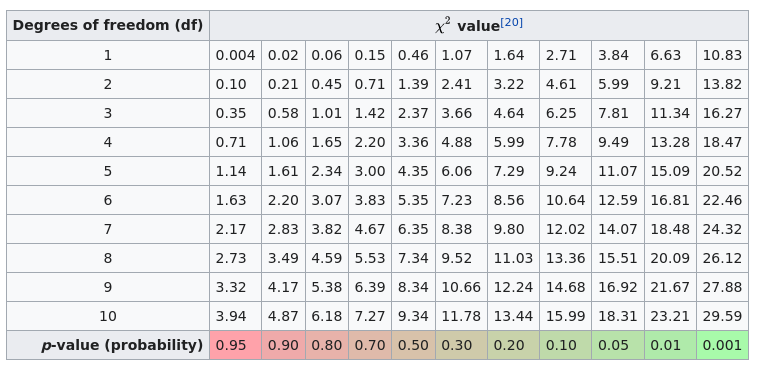

In [43]:
# looks like it's a small p-value to me ^
# I guess it's working properly for this simple, contrived example

In [44]:
"""
Single likelihood ratio tests

Modify the iterative solution function
"""
def iterative_soln_precision_single(coeffs_zero, H_s, C, dim, modify_index=0, iters=5):
    s_imo = coeffs_zero
    s_i = s_imo.copy()
    for it in range(iters):
        psi_hat = (s_imo.reshape(-1, 1, 1)*H_s).sum(0) # calculate psi_hat
        A, B = calc_matrices_precision(psi_hat, H_s, C, dim)
        t_i = inv(A).dot(B)
        s_i[modify_index] = s_imo[modify_index] + t_i[modify_index]
        print(s_i)
        s_imo = s_i
        
    return s_imo

In [45]:
# use the total data estimate coeffs as the initialized values for iterative solution
# iterative solution calculated using sample covariance of second half

# modify the first index of coeffs
mod_first_coeffs = iterative_soln_precision_single(coeffs_hat_total, H_s, C=C_two, dim=M, modify_index=0, iters=15)
# modify the second index of coeffs
mod_second_coeffs = iterative_soln_precision_single(coeffs_hat_total, H_s, C=C_two, dim=M, modify_index=1, iters=15)

[0.26757915 0.89893927]
[0.27242295 0.89893927]
[0.27248434 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.27248444 0.89893927]
[0.2264357  0.90296069]
[0.2264357  0.90308581]
[0.2264357  0.90308919]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]
[0.2264357  0.90308928]


In [46]:
mod_first_coeffs, mod_second_coeffs

(array([0.27248444, 0.89893927]), array([0.2264357 , 0.90308928]))

In [47]:
"""
Perform two hypothesis tests

First for a change in alpha_1, then a change in alpha_2

Start with alpha_1
"""

# likelihood using all the data to fit coefficients, using the first half of the data's cov matrix
likelihood_one = calc_likelihood_precision(coeffs_hat_total, H_s, C, N, P=dim)
# likelihood using the second half of data exclusively
likelihood_two = calc_likelihood_precision(mod_first_coeffs, H_s, C_two, N, P=dim)
# summation of the two above likelihoods
likelihood_alternative = likelihood_one + likelihood_two
# likelihood on all the data, whole covariance
likelihood_total = calc_likelihood_precision(coeffs_hat_total, H_s, C=total_cov, N=N*2, P=dim)
likelihood_one, likelihood_two, likelihood_total, likelihood_alternative

(-5632.800191453858,
 -5414.419771401407,
 -11052.22422143189,
 -11047.219962855266)

In [48]:
"""
calculate likelihood ratio
pretty sure this is now 1 DOF, single only alpha_1 modified
"""

likelihood_ratio = -2*(likelihood_total - likelihood_alternative)
likelihood_ratio, chi2.pdf(likelihood_ratio, 1)

(10.008517153248249, 0.0008460641847505998)

In [49]:
"""
Now alpha_2
"""

# likelihood using all the data to fit coefficients, using the first half of the data's cov matrix
likelihood_one = calc_likelihood_precision(coeffs_hat_total, H_s, C, N, P=dim)
# likelihood using the second half of data exclusively
likelihood_two = calc_likelihood_precision(mod_second_coeffs, H_s, C_two, N, P=dim)
# summation of the two above likelihoods
likelihood_alternative = likelihood_one + likelihood_two
# likelihood on all the data, whole covariance
likelihood_total = calc_likelihood_precision(coeffs_hat_total, H_s, C=total_cov, N=N*2, P=dim)
likelihood_one, likelihood_two, likelihood_total, likelihood_alternative

(-5632.800191453858,
 -5418.161510604194,
 -11052.22422143189,
 -11050.961702058052)

In [50]:
"""
calculate likelihood ratio
pretty sure this is now 1 DOF, single only alpha_2 modified

(not sure why this is coming up negative...)
"""

likelihood_ratio = -2*(likelihood_total - likelihood_alternative)
likelihood_ratio, chi2.pdf(likelihood_ratio, 1)

(2.525038747677172, 0.07103474814604484)

In [51]:
prec_coeffs, prec_coeffs_two, coeffs_hat_total, mod_first_coeffs, mod_second_coeffs

(array([0.19894754, 0.8568503 ]),
 array([0.29894754, 0.8568503 ]),
 array([0.2264357 , 0.89893927]),
 array([0.27248444, 0.89893927]),
 array([0.2264357 , 0.90308928]))

In [52]:
# is a bit sensitive I think

In [56]:
"""
Questions to ask:

Fit null model on entire data, including changepoint, then calc likelihood?
Or fit null model on "pre-changepoint" data, then calc likelihood on total dataset?

Alternative model uses hypothesis of multiple models:
null model vs null model pre-changepoint and additional model post-changepoint

Issue of what data to use for parameter estimation

For some reason, the likelihood ends up being slightly lower for some reason
sometimes when modifying the single coefficients for less data
Not sure why this is^, as it should be the same for the pre-changepoint data and 
fitting exclusively better on the post-changepoint data
Likely a computational issue
""";